In [1]:
import sys
from pathlib import Path
from dotenv import load_dotenv
env_path = Path(r"F:\code_repo\abTEM\.env")
load_dotenv(env_path)
import os
# print(os.getenv("Materials_Project_API_KEY"))

# 将项目根目录加入 Python 路径（从 notebooks 目录向上找到 multem_cgs 根目录）
project_root = Path.cwd()
for _ in range(10):
    if (project_root / "abTEM").exists() or (project_root / "materials").exists():
        break
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from abtem.multislice import CVDMSMultislice, FourierMultislice

# Materials Project 数据接口（从 abTEM 导入）
from abtem.materials import (
    fetch_structure,
    get_structure_by_id,
    mp_structure_to_atoms,
    search_materials,
    is_available,
)

In [2]:
# 检查依赖项
from abtem.materials.mp_client import MP_API_AVAILABLE, PYMATGEN_AVAILABLE, ASE_AVAILABLE
print(f"mp-api: {MP_API_AVAILABLE}")
print(f"pymatgen: {PYMATGEN_AVAILABLE}")
print(f"ase: {ASE_AVAILABLE}")


mp-api: True
pymatgen: True
ase: True


(examples:cbed_quickstart)=
# CBED quickstart

This notebook demonstrates a basic CBED simulation of silicon in the $(111)$ zone axis.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [3]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "cupy",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
);

## Atomic model
We create the atomic model. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models.

We fetch the crystal structure from the [Materials Project](https://materialsproject.org) database. Enter a material name to search, browse the available candidates, and pick one by index.

Retrieving SummaryDoc documents:   0%|          | 0/4 [00:00<?, ?it/s]

找到 4 个 'SrTiO3' 相关材料：

  # | MP ID        | 化学式        | 空间群        | 晶系           |    稳定 |   E_hull |    带隙
--------------------------------------------------------------------------------------
  0 | mp-4651      | SrTiO3     | I4/mcm     | Tetragonal   |     ✓ |   0.0000 | 1.849
  1 | mp-551830    | SrTiO3     | I4/mcm     | Tetragonal   |       |   0.0001 | 1.787
  2 | mp-5229      | SrTiO3     | Pm-3m      | Cubic        |       |   0.0005 | 1.772
  3 | mp-776018    | SrTiO3     | P6_3/mmc   | Hexagonal    |       |   0.0391 | 1.736


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

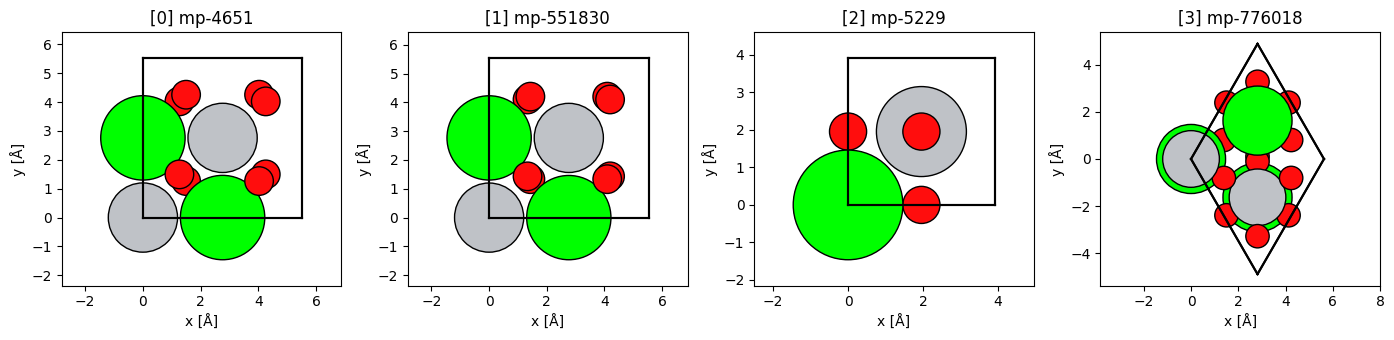

In [4]:
# ============================================================
# 从 Materials Project 搜索晶体结构
# ============================================================
# 在这里设置要模拟的材料名称
MATERIAL = "SrTiO3"

if not MATERIAL:
    raise ValueError("请设置 MATERIAL 变量")

if not is_available():
    raise RuntimeError(
        "Materials Project 不可用。请确保已配置 MP_API_KEY 环境变量，"
        "或安装 mp-api / pymatgen 依赖。"
    )

# 搜索材料
result = search_materials(MATERIAL, max_results=8)

if not result["success"]:
    raise RuntimeError(f"搜索失败: {result.get('error')}")
elif result["count"] == 0:
    raise ValueError(f"在 Materials Project 中未找到 '{MATERIAL}'")
else:
    candidates = result["results"]
    print(f"找到 {len(candidates)} 个 '{MATERIAL}' 相关材料：\n")

    # 打印候选列表
    header = f"{'#':>3} | {'MP ID':<12} | {'化学式':<10} | {'空间群':<10} | {'晶系':<12} | {'稳定':>5} | {'E_hull':>8} | {'带隙':>5}"
    print(header)
    print("-" * len(header))
    for i, m in enumerate(candidates):
        stable = "✓" if m["is_stable"] else " "
        spgr = m.get("space_group", "N/A") or "N/A"
        csys = m.get("crystal_system", "N/A") or "N/A"
        ehull = f"{m['energy_above_hull']:.4f}" if m["energy_above_hull"] is not None else "N/A"
        bgap = f"{m['band_gap']:.3f}" if m["band_gap"] is not None else "N/A"
        print(f"{i:>3} | {m['material_id']:<12} | {m['formula']:<10} | {spgr:<10} | {csys:<12} | {stable:>5} | {ehull:>8} | {bgap:>5}")

    # 可视化所有候选结构的晶胞
    n = len(candidates)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.atleast_1d(axes).ravel()
    for i, m in enumerate(candidates):
        struct = get_structure_by_id(m["material_id"], conventional=True)
        if struct["success"]:
            atoms_i = mp_structure_to_atoms(struct["structure"])
            abtem.show_atoms(atoms_i, ax=axes[i], title=f"[{i}] {m['material_id']}")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()




使用: [2] mp-5229 (SrTiO3)


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

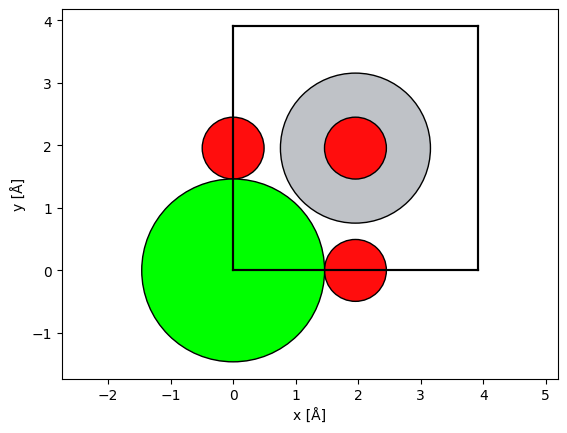

In [5]:
# ============================================================
# 选择使用哪个结构 — 改这个索引即可切换
SELECTED_INDEX = 2
# ============================================================

selected = candidates[SELECTED_INDEX]
print(f"\n使用: [{SELECTED_INDEX}] {selected['material_id']} ({selected['formula']})")
struct = get_structure_by_id(selected["material_id"], conventional=True)
structure = mp_structure_to_atoms(struct["structure"])

abtem.show_atoms(structure, plane="xy");

We can choose the $(111)$ zone axis to be a propagation direction using the `surface` function. 

Finally we repeat the structure in $x$ and $y$, this will improve the reciprocal space resolution. We also repeat the structure in $z$, thus simulating a thicker sample.

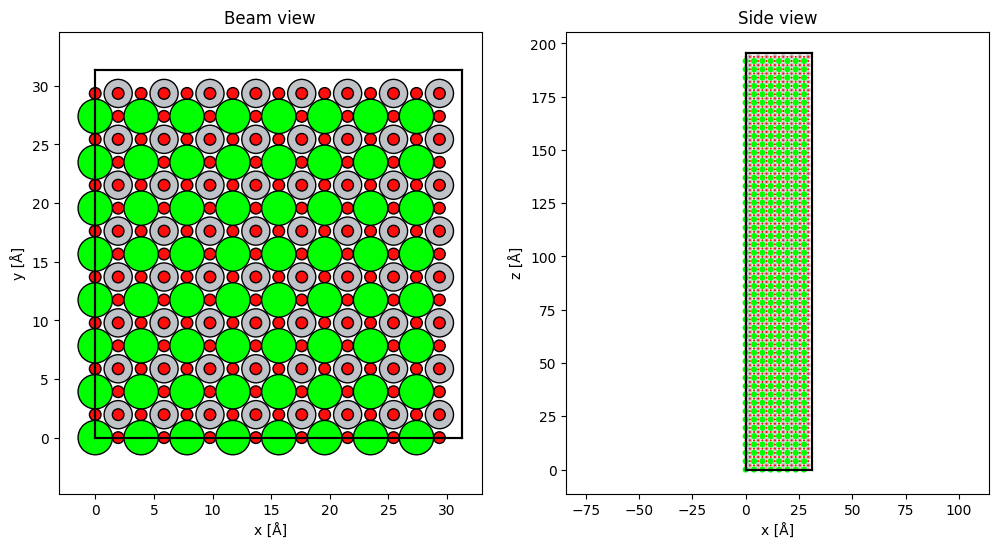

In [6]:
#structure = abtem.orthogonalize_cell(structure)
atoms = structure * (8, 8, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
abtem.show_atoms(atoms, ax=ax1, title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", linewidth=0.0);

## Potential

We create an ensemble of potentials using the frozen phonon. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [7]:
frozen_phonons = abtem.FrozenPhonons(atoms, 32, {"Sr":0.164356, "Ti": 0.116584, "O": 0.148198})

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [8]:
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.05,
    projection="finite",
    slice_thickness=0.4,
    exit_planes=60,
)

total_z = atoms.cell[2, 2]

# 采样信息
gx, gy = potential.gpts
sx, sy = potential.sampling
lx, ly = potential.extent
sz = potential.slice_thickness[0]
dkx = 1.0 / lx
dky = 1.0 / ly
dkz = 1.0 / total_z

n_slices = int(total_z / sz)
print(f"Thickness: {total_z:.2f} A, slices: {n_slices}")

print(f"Grid: {gx} x {gy}")
print(f"Real-space sampling: dx={sx:.4f} A, dy={sy:.4f} A, dz={sz:.4f} A")
print(f"Extent: Lx={lx:.2f} A, Ly={ly:.2f} A, Lz={total_z:.2f} A")
print(f"Reciprocal-space sampling: dkx={dkx:.6f} 1/A, dky={dky:.6f} 1/A, dkz={dkz:.6f} 1/A")
print(f"Nyquist freq: kx_max={gx*dkx/2:.4f} 1/A, ky_max={gy*dky/2:.4f} 1/A")

Thickness: 195.64 A, slices: 490
Grid: 627 x 627
Real-space sampling: dx=0.0499 A, dy=0.0499 A, dz=0.3993 A
Extent: Lx=31.30 A, Ly=31.30 A, Lz=195.64 A
Reciprocal-space sampling: dkx=0.031947 1/A, dky=0.031947 1/A, dkz=0.005112 1/A
Nyquist freq: kx_max=10.0155 1/A, ky_max=10.0155 1/A


## Wave function

We create a probe wave function at an energy of 100 keV with a convergence semiangle of $9.4 \ \mathrm{mrad}$. See our [walkthrough on wave functions](walkthrough:wave_functions). 

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence) if you want to include this in your simulation.

In [9]:
wave = abtem.Probe(energy=30e3, semiangle_cutoff=35)
wave.grid.match(potential)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

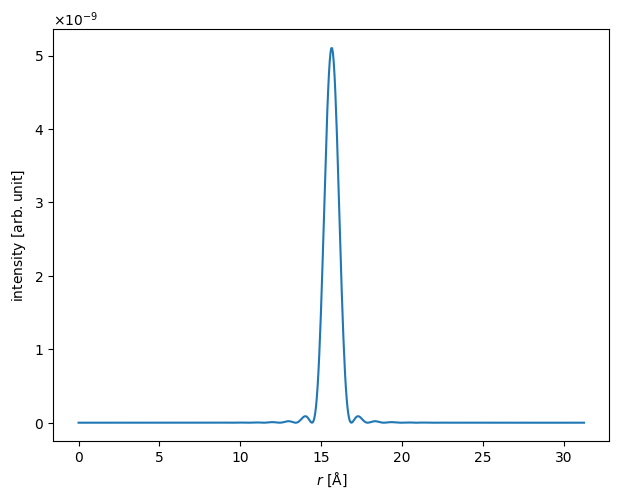

In [10]:
wave.profiles().show();

## Multislice with CVDMS

We run the multislice algorithm using the **CVDMS (Coupled-Wave Dynamical Multislice)** algorithm, which accounts for backscattering coupling between slices for higher accuracy compared to the conventional Fourier multislice method.

We configure the algorithm with explicit parameter control: order-1 expansion with backscattering corrections enabled.

In [11]:
cvdms_algorithm = CVDMSMultislice(
    convergence_threshold=1e-7,
    max_terms=50,
    use_fused_kernel=True,
    backscattering=True,
    check_interval=2,  # 2
)

measurements = wave.multislice(
    potential,
    algorithm=cvdms_algorithm,#FourierMultislice(order=1),
).diffraction_patterns(max_angle="cutoff")

We take the mean across the frozen phonons axis, and compute the result.

In [12]:
measurement = measurements.mean(0)

measurement.compute();

tasks:   0%|          | 0/130 [00:00<?, ?it/s]

[cvdms] Using C++ CUDA backend


multislice:   1%|          | 5/490 [00:00<01:06,  7.33it/s]

## Visualize results

We show the thickness series as an exploded plot.

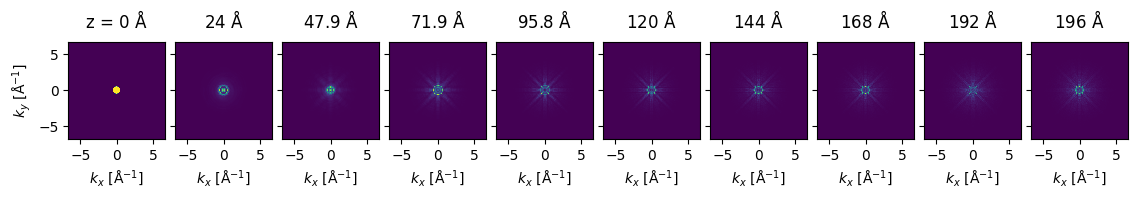

In [13]:
visualization = measurement.show(
    explode=True,
    figsize=(12, 5),
)

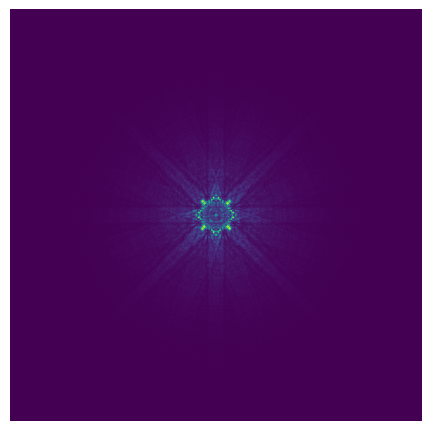

In [14]:
# this cell produces a thumbnail for the online documentation

visualization = measurement[-1].show()
visualization.axis_off()
plt.savefig("cbed_quickstart.png", bbox_inches="tight", pad_inches=0)

In [15]:
arr = measurement.array
if hasattr(arr, 'get'):
    arr = arr.get()

img = np.asarray(arr)
while img.ndim > 2:
    img = img[-1]

try:
    ang = getattr(measurement, 'angular_sampling', None)
    if ang is not None:
        ang = (float(ang[0]), float(ang[1]))
except Exception:
    ang = None

try:
    mx = getattr(measurement, 'max_angles', None)
    if mx is not None:
        mx = (float(mx[0]), float(mx[1]))
except Exception:
    mx = None

try:
    pot_gpts = getattr(potential, 'gpts', None)
except Exception:
    pot_gpts = None

print('potential shape (gpts):', pot_gpts)
print('CBED pattern shape (raw):', img.shape)
print('angular_sampling (mrad/px):', ang)
print('max_angles (mrad):', mx)

potential shape (gpts): (627, 627)
CBED pattern shape (raw): (419, 419)
angular_sampling (mrad/px): (2.2296237918408934, 2.2296237918408934)
max_angles (mrad): (465.9913724947467, 465.9913724947467)


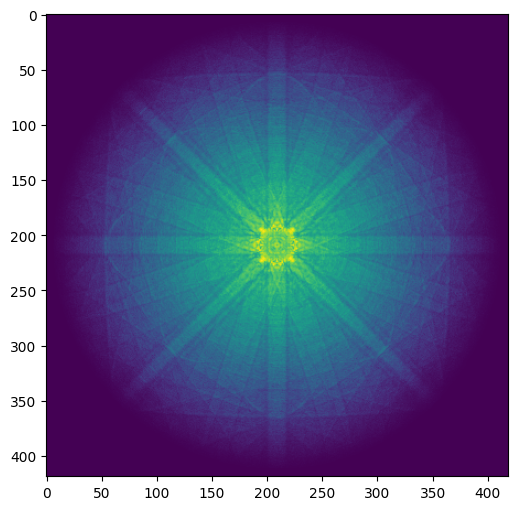

In [16]:
fix, ax = plt.subplots(1, 1, figsize=(6, 6))
# Match the notebook convention: log(transpose(last_exit_plane)).
with np.errstate(divide='ignore', invalid='ignore'):
    C = 1.5e3
    ax.imshow(np.log(1+C*img/np.max(img)), cmap="viridis")

plt.savefig("cvdms_cbed.png", dpi=300)
plt.show()

## Self-Consistency Verification

We verify the physical self-consistency of the multislice algorithms (Fourier, CVDMS, CVDMS+BSC)

by checking intensity conservation, Parseval's theorem, and BSC wave function properties.

**Notes for CBED**:

- A3 (Friedel's law) is skipped: the converged probe breaks centrosymmetry of the incident beam.

- B-checks use a reduced structure (8×8×10) due to GPU memory constraints from per-slice BSC storage.

- A single static configuration (no frozen phonons) is used to isolate algorithm correctness.

Full potential: grid=(627, 627), exit_planes=10, slices=490

Computing Fourier reference...


Computing CVDMS (no BSC)...


Computing CVDMS + BSC...


I0 = 0.000003, N_pix = 393129

Method           EP        I/I0      Parseval
----------------------------------------------
Fourier           0    1.000000    0.99999995
Fourier           1    0.983532    0.99999990
Fourier           2    0.977530    1.00000010
Fourier           8    0.944704    1.00000003
Fourier           9    0.944056    0.99999993
  --> min=0.944056, max excess=+0.0000%
----------------------------------------------
CVDMS             0    1.000000    0.99999995
CVDMS             1    0.995952    0.99999980
CVDMS             2    0.980819    0.99999999
CVDMS             8    0.897583    0.99999983
CVDMS             9    0.890682    1.00000007
  --> min=0.890682, max excess=+0.0000%
----------------------------------------------
CVDMS+BSC         0    1.000000    0.99999995
CVDMS+BSC         1    1.016234    0.99999994
CVDMS+BSC         2    1.002471    1.00000000
CVDMS+BSC         8    0.916313    0.99999999
CVDMS+BSC         9    0.912890    1.00000001
  --> min=0.

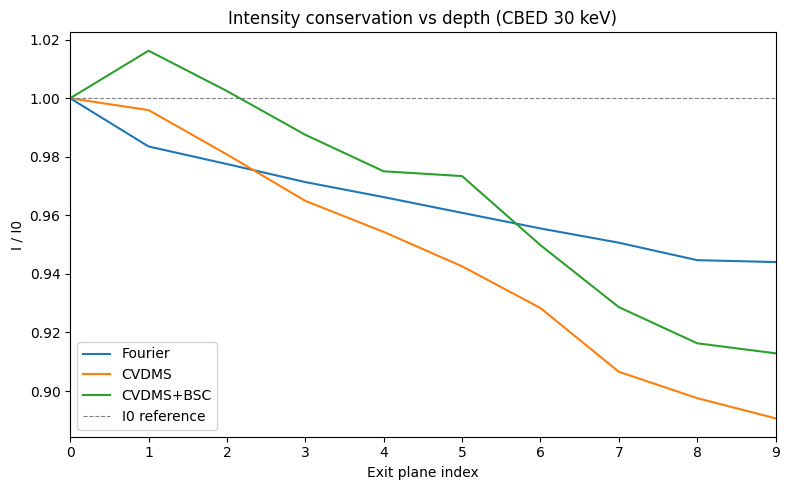


PART B: BSC checks (reduced 8x8x10, ct=1e-6)
Grid: (627, 627), Exit planes: 11, Slices: 98


Computing CVDMS+BSC with return_backscattered=True...


B1 Bottom=0: max|BSC[bottom]|=0.00e+00  PASS
B2 Monotonicity: FAIL  ['6.23e-10', '6.34e-10', '7.22e-10', '7.02e-10', '6.01e-10', '4.97e-10', '5.54e-11', '2.95e-11', '1.26e-11', '2.37e-12', '0.00e+00']
B3 Amplitude: max|BSC[entrance]|=2.81e-06  PASS
B4 Energy: forward loss=-0.5331%, BSC/I0=2.4493e-04  PASS


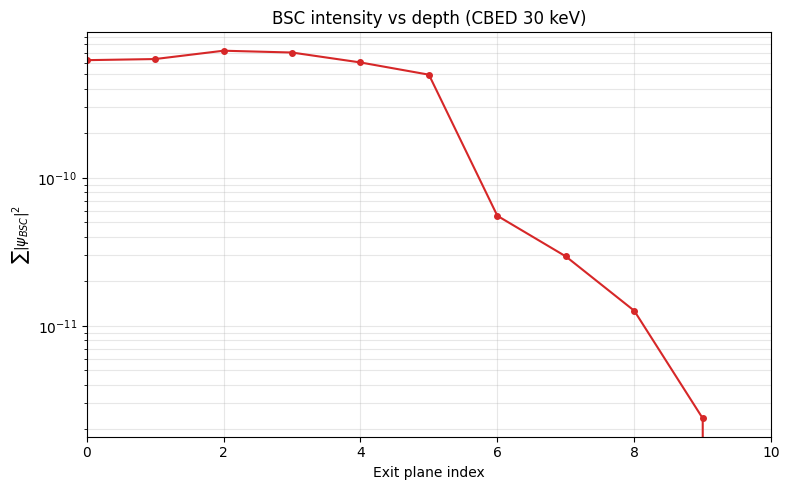


Self-Consistency Summary (CBED 30 keV, ct=1e-6)
  [A1] Intensity conservation         PASS
  [A2] Parseval theorem               PASS
  [A3] Friedel's law                  SKIP
  [A4] Phase object                   PASS
  [B1] BSC bottom = 0                 PASS
  [B2] BSC depth monotonicity         FAIL
  [B3] BSC amplitude scale            PASS
  [B4] Energy budget                  PASS
  Total: 6/7 PASS


In [18]:
import gc
import cupy as cp

def _cleanup():
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

# ── Build single-configuration potentials ──────────────────────────
# Use the same atoms (8,8,50) but without frozen phonons for algorithm checks
atoms_sc = structure * (8, 8, 50)

pot_full = abtem.Potential(atoms_sc, sampling=0.05, slice_thickness=0.4, exit_planes=60)
num_ep = pot_full.num_exit_planes
ns = len([s for s in pot_full])
print(f"Full potential: grid={pot_full.gpts}, exit_planes={num_ep}, slices={ns}")

wave_sc = abtem.Probe(energy=30e3, semiangle_cutoff=35)
wave_sc.grid.match(pot_full)
_cleanup()

# ── CT matching notebook ───────────────────────────────────────────
CT = 1e-6

# ═══════════════════════════════════════════════════════════════════
# PART A: Forward wave checks (no BSC return needed)
# ═══════════════════════════════════════════════════════════════════
print("\nComputing Fourier reference...")
ref_fourier = wave_sc.multislice(pot_full, algorithm=FourierMultislice(), lazy=False)
print("Computing CVDMS (no BSC)...")
ref_cvdms = wave_sc.multislice(pot_full,
    algorithm=CVDMSMultislice(convergence_threshold=CT), lazy=False)
print("Computing CVDMS + BSC...")
ref_bsc = wave_sc.multislice(pot_full,
    algorithm=CVDMSMultislice(backscattering=True, calculate_backscattered=True,
        convergence_threshold=CT),
    return_backscattered=False, lazy=False)

# I0 from first exit plane
psi0 = ref_fourier.array[0]
if hasattr(psi0, "get"): psi0 = psi0.get()
I0 = float(np.sum(np.abs(psi0) ** 2))
N_pix = psi0.size
print(f"I0 = {I0:.6f}, N_pix = {N_pix}")

# ── A1 + A2 ──
waves_fwd = [
    ("Fourier", ref_fourier),
    ("CVDMS", ref_cvdms),
    ("CVDMS+BSC", ref_bsc),
]

print(f"\n{'Method':<14s} {'EP':>4s}  {'I/I0':>10s}  {'Parseval':>12s}")
print("-" * 46)
all_a1_pass = True
all_a2_pass = True
a1_ratios = {}

for name, wave in waves_fwd:
    a1_ratios[name] = []
    for ep in range(num_ep):
        psi = wave.array[ep]
        if hasattr(psi, "get"): psi = psi.get()
        I_ep = float(np.sum(np.abs(psi) ** 2))
        ratio_a1 = I_ep / I0
        a1_ratios[name].append(ratio_a1)
        I_recip = float(np.sum(np.abs(np.fft.fft2(psi)) ** 2)) / psi.size
        ratio_a2 = I_ep / max(I_recip, 1e-30)
        a1_ok = abs(ratio_a1 - 1.0) < 0.15
        a2_ok = abs(ratio_a2 - 1.0) < 1e-5
        all_a1_pass = all_a1_pass and a1_ok
        all_a2_pass = all_a2_pass and a2_ok
        if ep < 3 or ep >= num_ep - 2:
            print(f"{name:<14s} {ep:>4d}  {ratio_a1:10.6f}  {ratio_a2:12.8f}")

    ratios = a1_ratios[name]
    print(f"  --> min={min(ratios):.6f}, max excess={max(r-1 for r in ratios)*100:+.4f}%")
    print("-" * 46)

print(f"A1 Intensity: {'PASS' if all_a1_pass else 'FAIL'}")
print(f"A2 Parseval:  {'PASS' if all_a2_pass else 'FAIL'}")

# ── A3: SKIP for CBED ──
print("A3 Friedel: SKIP (converged probe breaks centrosymmetry)")

# ── A4: Phase object ──
max_imag = 0.0
for sl in pot_full:
    V = sl.array
    if hasattr(V, "get"): V = V.get()
    max_imag = max(max_imag, float(np.max(np.abs(np.imag(V)))))
a4_ok = max_imag < 1e-10
print(f"A4 Phase object: max|Im(V)|={max_imag:.2e}  {'PASS' if a4_ok else 'FAIL'}")

# ── A1 intensity-depth plot ──
fig, ax = plt.subplots(figsize=(8, 5))
ep_axis = np.arange(num_ep)
colors = {"Fourier": "#1f77b4", "CVDMS": "#ff7f0e", "CVDMS+BSC": "#2ca02c"}
for name in ["Fourier", "CVDMS", "CVDMS+BSC"]:
    ax.plot(ep_axis, a1_ratios[name], label=name, color=colors[name], lw=1.5)
ax.axhline(1.0, color="gray", ls="--", lw=0.8, label="I0 reference")
ax.set_xlabel("Exit plane index")
ax.set_ylabel("I / I0")
ax.set_title("Intensity conservation vs depth (CBED 30 keV)")
ax.legend()
ax.set_xlim(0, num_ep - 1)
fig.tight_layout()
plt.show()

del ref_fourier, ref_cvdms, ref_bsc
_cleanup()

# ═══════════════════════════════════════════════════════════════════
# PART B: BSC wave checks (reduced structure for GPU memory)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PART B: BSC checks (reduced 8x8x10, ct=1e-6)")
print("=" * 60)

atoms_small = structure * (8, 8, 10)
pot_bsc = abtem.Potential(atoms_small, sampling=0.05, slice_thickness=0.4, exit_planes=10)
num_ep_b = pot_bsc.num_exit_planes
ns_b = len([s for s in pot_bsc])
print(f"Grid: {pot_bsc.gpts}, Exit planes: {num_ep_b}, Slices: {ns_b}")
_cleanup()

probe_b = abtem.Probe(energy=30e3, semiangle_cutoff=35)
probe_b.grid.match(pot_bsc)

ref_b0 = probe_b.multislice(pot_bsc, algorithm=FourierMultislice(), lazy=False)
psi0_b = ref_b0.array[0]
if hasattr(psi0_b, "get"): psi0_b = psi0_b.get()
I0_b = float(np.sum(np.abs(psi0_b) ** 2))
del ref_b0
_cleanup()

print("Computing CVDMS+BSC with return_backscattered=True...")
b1_ok = b2_ok = b3_ok = b4_ok = False
bsc_I = []
try:
    result_bsc = probe_b.multislice(
        pot_bsc,
        algorithm=CVDMSMultislice(
            backscattering=True, calculate_backscattered=True,
            convergence_threshold=CT
        ),
        return_backscattered=True, lazy=False,
    )
    ew_bsc, bw = result_bsc[0], result_bsc[-1]

    # B1: Bottom = 0
    b1 = float(np.max(np.abs(
        bw.array[-1].get() if hasattr(bw.array[-1], 'get') else bw.array[-1]
    )))
    b1_ok = b1 < 1e-10
    print(f"B1 Bottom=0: max|BSC[bottom]|={b1:.2e}  {'PASS' if b1_ok else 'FAIL'}")

    # B2: Depth monotonicity
    for ep in range(num_ep_b):
        b_ep = bw.array[ep]
        if hasattr(b_ep, "get"): b_ep = b_ep.get()
        bsc_I.append(float(np.sum(np.abs(b_ep) ** 2)))
    b2_ok = all(bsc_I[i] >= bsc_I[i+1]*0.99 for i in range(num_ep_b-1))
    print(f"B2 Monotonicity: {'PASS' if b2_ok else 'FAIL'}  {[f'{v:.2e}' for v in bsc_I]}")

    # B3: Amplitude scale (CBED probe → much smaller BSC vs plane wave)
    b3 = float(np.max(np.abs(
        bw.array[0].get() if hasattr(bw.array[0], 'get') else bw.array[0]
    )))
    # CBED probe: BSC ~1e-6 (vs plane wave ~1e-3). Use relative threshold.
    b3_ok = 1e-7 < b3 < 1e-4
    print(f"B3 Amplitude: max|BSC[entrance]|={b3:.2e}  {'PASS' if b3_ok else 'FAIL'}")

    # B4: Energy budget
    psi_exit = ew_bsc.array[-1]
    if hasattr(psi_exit, "get"): psi_exit = psi_exit.get()
    forward_loss = (I0_b - float(np.sum(np.abs(psi_exit) ** 2))) / I0_b
    bsc_frac = bsc_I[0] / I0_b
    b4_ok = abs(forward_loss) < 0.15 and bsc_frac < 0.01
    print(f"B4 Energy: forward loss={forward_loss*100:+.4f}%, BSC/I0={bsc_frac:.4e}  {'PASS' if b4_ok else 'FAIL'}")

    # ── BSC depth profile plot ──
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    ax2.semilogy(np.arange(num_ep_b), bsc_I, "o-", color="#d62728", lw=1.5, markersize=4)
    ax2.set_xlabel("Exit plane index")
    ax2.set_ylabel(r"$\sum |\psi_{BSC}|^2$")
    ax2.set_title("BSC intensity vs depth (CBED 30 keV)")
    ax2.set_xlim(0, num_ep_b - 1)
    ax2.grid(True, which="both", alpha=0.3)
    fig2.tight_layout()
    plt.show()

    del result_bsc
except Exception as e:
    print(f"BSC checks FAILED: {type(e).__name__}: {str(e)[:200]}")

_cleanup()

# ═══════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("Self-Consistency Summary (CBED 30 keV, ct=1e-6)")
print("=" * 60)
checks = [
    ("A1", "Intensity conservation", all_a1_pass),
    ("A2", "Parseval theorem", all_a2_pass),
    ("A3", "Friedel's law", "SKIP"),
    ("A4", "Phase object", a4_ok),
    ("B1", "BSC bottom = 0", b1_ok),
    ("B2", "BSC depth monotonicity", b2_ok),
    ("B3", "BSC amplitude scale", b3_ok),
    ("B4", "Energy budget", b4_ok),
]
for tag, desc, ok in checks:
    status = "PASS" if ok is True else ("SKIP" if ok == "SKIP" else "FAIL")
    print(f"  [{tag}] {desc:<30s} {status}")
n_pass = sum(1 for _, _, ok in checks if ok is True)
n_total = sum(1 for _, _, ok in checks if ok != "SKIP")
print(f"  Total: {n_pass}/{n_total} PASS")